In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [63]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

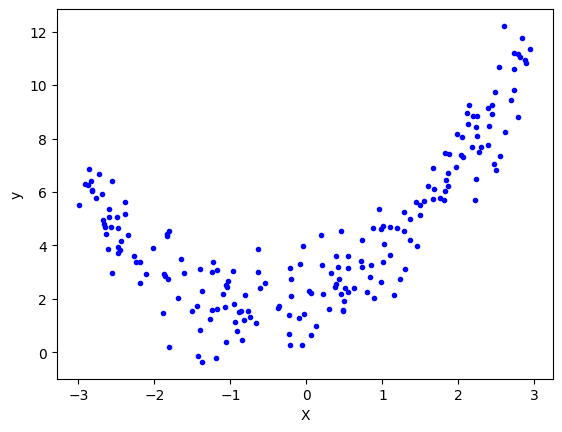

In [66]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [67]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [68]:
# Applying linear regression
lr = LinearRegression()

In [69]:
lr.fit(X_train,y_train)

LinearRegression()

In [70]:
X_random = np.random.uniform(-3,3,size=(100,1))
y_random = lr.predict(X_random)


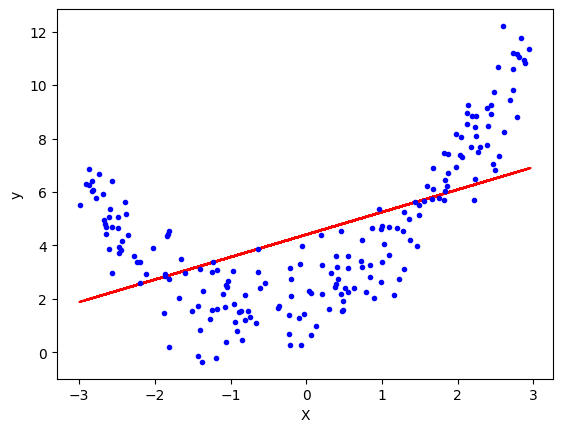

In [71]:
plt.plot(X_random,y_random,'r-')
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [72]:
# using polynomial features
poly_features = PolynomialFeatures(degree=2,include_bias=True)
X_poly = poly_features.fit_transform(X)

In [73]:
lr = LinearRegression()
lr.fit(X_poly,y)

LinearRegression()

In [74]:
y_pred = lr.predict(X_poly)

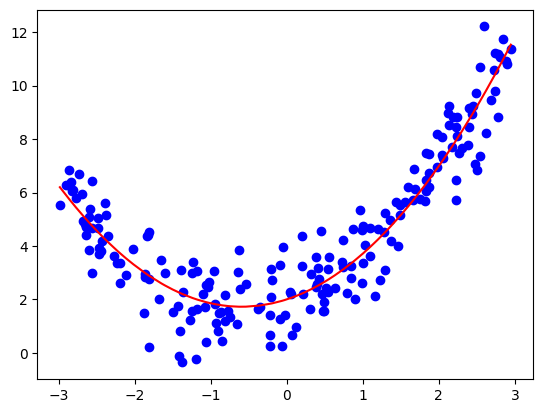

In [84]:
plt.scatter(X, y, color='blue')

# Sort for a smooth curve
idx = np.argsort(X[:, 0])

plt.plot(X[idx], y_pred[idx], color='red')
plt.show()

In [88]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly_features.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

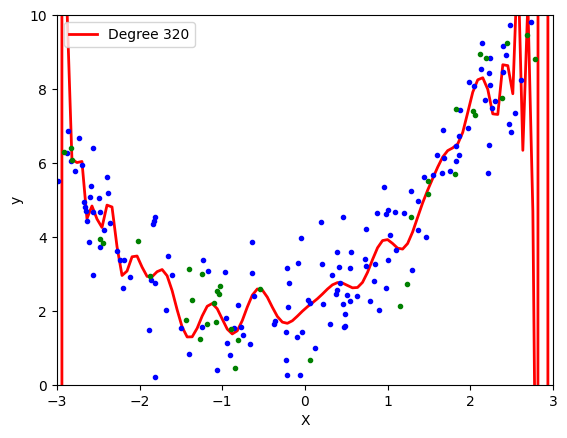

In [90]:
polynomial_regression(degree = 320)